In [26]:
# loading libraries for data manipulation
import numpy as np
import pandas as pd

# loading libraries for data visualization
import matplotlib.pyplot as plt
from plotnine import *

# other helpers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# import tensorflow and keras packages
import tensorflow as tf
from tensorflow import keras

import warnings
warnings.filterwarnings('ignore')

Here's a single neuron with some input, weights, and a bias value. We can also calculate the weighted sum before the value is passed to an activation function. 

In [27]:
x = np.array([0.8, 1.2])   # input features
w = np.array([0.6, -0.1])  # weights
b = 0.1                    # bias
z = np.dot(w, x) + b
print(z)

0.45999999999999996


Activation functions create a non-linear output (excluding step and linear activation) for which a gradient can be calculated. 
Here, we will plot sigmoid, tanh, and ReLU activation function output. 

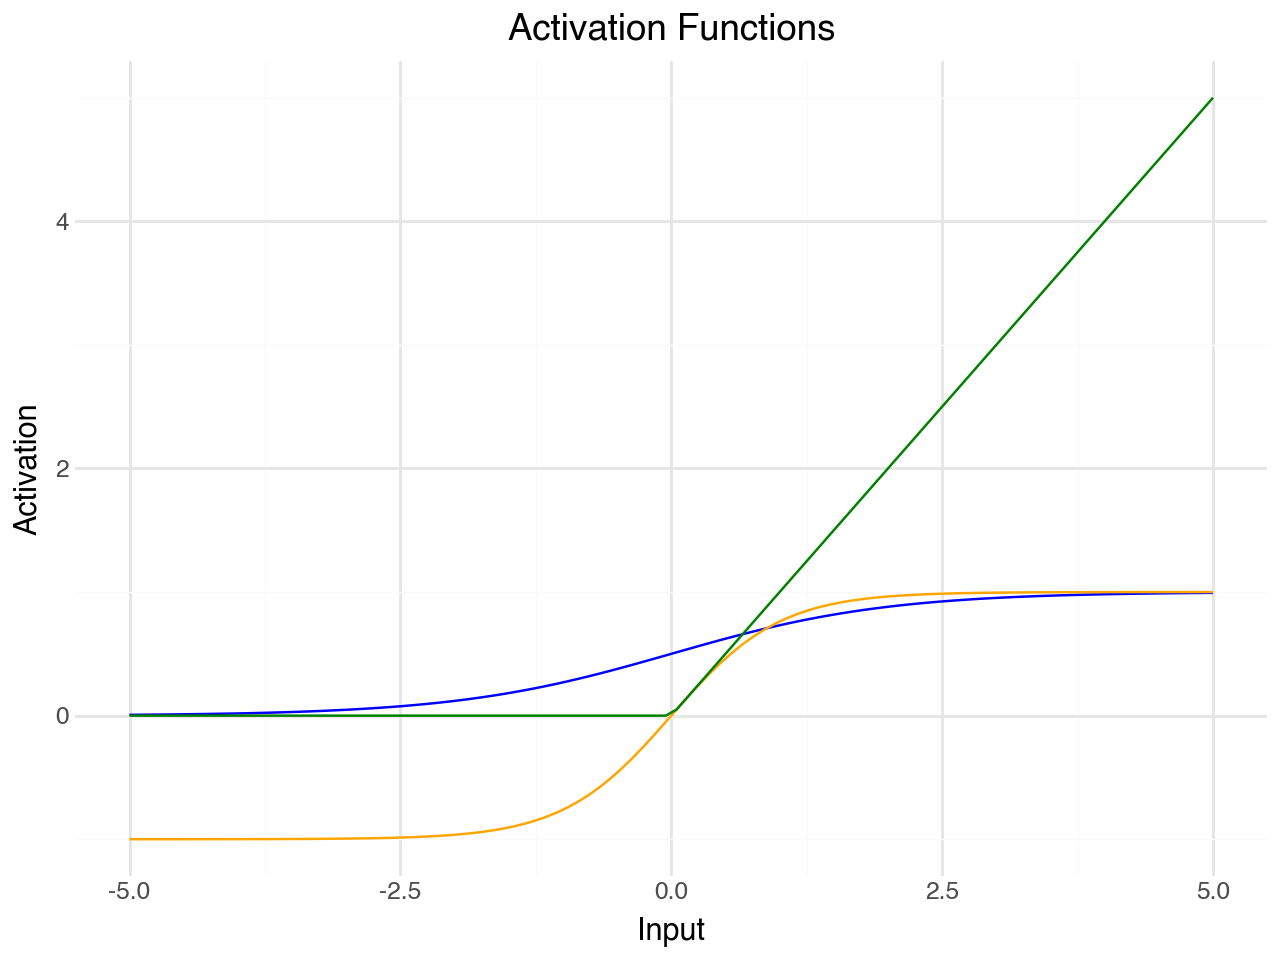

In [28]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def tanh(z):
    return np.tanh(z)

def relu(z):
    return np.maximum(0, z)

x_values = np.linspace(-5, 5, 100)

df_activations = pd.DataFrame({
    'x':x_values,
    'sigmoid' : sigmoid(x_values),
    'tanh' : tanh(x_values),
    'relu' : relu(x_values) 
})

(
    ggplot(df_activations)+
    geom_line(aes(x='x', y='sigmoid'), color='blue')+
    geom_line(aes(x='x', y='tanh'), color='orange')+
    geom_line(aes(x='x', y='relu'), color='green')+
    labs(title='Activation Functions', x='Input', y='Activation')+
    theme_minimal()
)

Let's train a linear regression model using the building blocks of a neural network implementation. 

When building a neural network, think of the following key items:
- The structure of your model (how many nodes/layers? which activation function to use?)
- The loss function of your model
- The optimizer you will use to train the model

The input and output layers are determined by your feature space (size and type of input) and the target (what form of output you expect). For a regression problem, your output layer will have a single node. For a multi-class classification, it will be n nodes representing n classes. 

In [29]:
# first we load our data
df = pd.read_csv("https://raw.githubusercontent.com/cristobalvch/Spotify-Machine-Learning/refs/heads/master/data/data_moods.csv")
df.head()


,name,album,artist,id,release_date,popularity,length,danceability,acousticness,energy,instrumentalness,liveness,valence,loudness,speechiness,tempo,key,time_signature,mood
0,1999,1999,Prince,2H7PHVdQ3mXqEHXcvclTB0,1982-10-27,68,379266,0.866,0.13700,0.730,0.000000,0.0843,0.625,-8.201,0.0767,118.523,5,4,Happy
1,23,23,Blonde Redhead,4HIwL9ii9CcXpTOTzMq0MP,2007-04-16,43,318800,0.381,0.01890,0.832,0.196000,0.1530,0.166,-5.069,0.0492,120.255,8,4,Sad
2,9 Crimes,9,Damien Rice,5GZEeowhvSieFDiR8fQ2im,2006-11-06,60,217946,0.346,0.91300,0.139,0.000077,0.0934,0.116,-15.326,0.0321,136.168,0,4,Sad
3,99 Luftballons,99 Luftballons,Nena,6HA97v4wEGQ5TUClRM0XLc,1984-08-21,2,233000,0.466,0.08900,0.438,0.000006,0.1130,0.587,-12.858,0.0608,193.100,4,4,Happy
4,A Boy Brushed Red Living In Black And White,They're Only Chasing Safety,Underoath,47IWLfIKOKhFnz1FUEUIkE,2004-01-01,60,268000,0.419,0.00171,0.932,0.000000,0.1370,0.445,-3.604,0.1060,169.881,1,4,Energetic


In [30]:
# let's define our feature space and target
# we will predict 'energy' using the other features

features = ['danceability','popularity','length','acousticness','energy','instrumentalness','liveness','valence','loudness','speechiness','tempo']

X = df[features]
y = df['energy']

In [31]:
# let's also standardize our feature space

# split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


### Building blocks of a neural network in Tensorflow/Keras


#### Model Structure

| **Component**   | **Function / Parameter**                                | **Description**                                              |
| --------------- | ------------------------------------------------------- | ------------------------------------------------------------ |
| **Model**       | `tf.keras.Sequential()` or subclass of `tf.keras.Model` | Container that defines the model architecture.               |
| **Layers**      | `tf.keras.layers.Dense(units, activation)`              | Fully connected layers used to build the model.              |
| **Units**       | `units=...`                                             | Number of neurons in a layer.                                |
| **Activation**  | `activation='relu'`, `'sigmoid'`, `'softmax'`           | Function applied to layer output to introduce non-linearity. |
| **Input Shape** | `input_shape=(...)`                                     | Shape of input data (required in the first layer).           |

#### Compiling

| **Component**     | **Function / Parameter**                    | **Description**                                                          |
| ----------------- | ------------------------------------------- | ------------------------------------------------------------------------ |
| **Compile**       | `model.compile()`                           | Prepares the model for training by setting loss, optimizer, and metrics. |
| **Loss Function** | `loss='mse'`, `'binary_crossentropy'`, etc. | Measures the difference between predictions and actual values.           |
| **Optimizer**     | `optimizer='sgd'`, `'adam'`, etc.           | Algorithm to update weights based on gradients.                          |
| **Metrics**       | `metrics=['accuracy']`, etc.                | List of metrics to evaluate during training/testing.                     |

#### Training and Evaluation

| **Component**  | **Function / Parameter**         | **Description**                                         |
| -------------- | -------------------------------- | ------------------------------------------------------- |
| **Fit**        | `model.fit(X, y, epochs=...)`    | Trains the model using input data and labels.           |
| **Epochs**     | `epochs=...`                     | Number of complete passes through the training data.    |
| **Batch Size** | `batch_size=...`                 | Number of samples processed before model weight update. |
| **Evaluate**   | `model.evaluate(X_test, y_test)` | Tests model performance on new data.                    |
| **Predict**    | `model.predict(X_new)`           | Uses the model to make predictions on new data.         |

#### Other Blocks

| **Component**     | **Function / Parameter**                     | **Description**                                                         |
| ----------------- | -------------------------------------------- | ----------------------------------------------------------------------- |
| **Model Weights** | `model.get_weights()`, `model.set_weights()` | Access or modify model parameters directly.                             |
| **Callbacks**     | `callbacks=[...]`                            | Tools like early stopping, learning rate scheduling, and checkpointing. |


In [32]:
# lets build a simple neural network: one neuron, no activation function

model = tf.keras.Sequential([
    tf.keras.layers.Dense(1,input_shape=(X_train.shape[1],),activation = None)
])

# compile the model
model.compile(optimizer='sgd', loss='mse')

# train the model
model.fit(X_train,y_train,epochs=10,verbose=1)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 638us/step - loss: 0.7710
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 584us/step - loss: 0.3659
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 532us/step - loss: 0.1989
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 559us/step - loss: 0.1159
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 545us/step - loss: 0.0730
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 566us/step - loss: 0.0481
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 546us/step - loss: 0.0351
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 502us/step - loss: 0.0273
Epoch 9/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 547us/step - loss: 0.0231
Epoch 10/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 516us/step - loss: 0.0203


During each epoch:  (actually done in batches but we will discuss this later)
- 1. Forward Pass: model makes prediction on X_train observations
- 2. Loss Computation: MSE is calculated between predicted and true values
- 3. Backpropagation: gradients are computed with respect to weights
- 4. SDG Optimizer: updates weights
- 5. Repeat

In [33]:
# print learned weights and bias
weights, bias = model.layers[0].get_weights()
print("Weights:", weights.flatten())
print("Bias:", bias)

Weights: [-3.5705573e-03 -2.3631047e-02 -1.1205669e-02 -2.3866366e-01
 -6.2542424e-02  5.1881485e-03  1.0510832e-02  2.3362836e-02
  1.3701956e-01  4.1605793e-02  2.6867609e-05]
Bias: [0.49243554]


In [34]:
# evaluate model

mse = model.evaluate(X_train, y_train, verbose=0)
print("Mean Squared Error on training set:", mse)

mse = model.evaluate(X_test, y_test, verbose=0)
print("Mean Squared Error on test set:", mse)

Mean Squared Error on training set: 0.019086657091975212
Mean Squared Error on test set: 0.017453491687774658


Let's build a deep neural network - that means adding some hidden layers! Recall that if no activation function is used then all layers combine into a single linear combination. 

In [39]:
# build a deep neural network with multiple layers and activation functions

deep_model = tf.keras.Sequential([
    tf.keras.layers.Dense(8,activation='relu',input_shape=(X_train.shape[1],)), # hidden layer 1
    tf.keras.layers.Dense(4,activation='relu'), # hidden layer 2
    tf.keras.layers.Dense(1,activation=None), # output layer
])

# compile the model
deep_model.compile(optimizer='sgd', loss='mse')

# train the model
deep_model.fit(X_train, y_train, epochs=30, verbose=1)

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 578us/step - loss: 0.2930
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 546us/step - loss: 0.1722
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/step - loss: 0.1356
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 542us/step - loss: 0.1146
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 522us/step - loss: 0.1024
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 515us/step - loss: 0.0936
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 502us/step - loss: 0.0871
Epoch 8/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 518us/step - loss: 0.0814
Epoch 9/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 469us/step - loss: 0.0771
Epoch 10/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 516us/step - loss: 0.0735
Epoch 11/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 487us/step - loss: 0.0706
Epoch 12/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 516us/step - loss: 0.0681
Epoch 13/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 508us/step - loss: 0.0658
Epoch 14/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 488us/step - loss: 0.0636
Epoch 15/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 516us/step - lo

In [40]:
# evaluate deep_model
mse = deep_model.evaluate(X_train, y_train, verbose=0)
print("Mean Squared Error on training set:", mse)

mse = deep_model.evaluate(X_test, y_test, verbose=0)
print("Mean Squared Error on test set:", mse)

Mean Squared Error on training set: 0.043332815170288086
Mean Squared Error on test set: 0.04266907274723053


The summary() function gives you the architecture of the model you have built. It can be used to validate the architecture and understand the number of parameters (weights) being learned.

In [41]:
deep_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 139 (560.00 B)

 Trainable params: 137 (548.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

You can also access the weights per layer as shown below. The first array contains the weights per node and the second array contains the bias terms. Here we are looking at the weights applied to the first hidden layer. 

In [42]:
deep_model.layers[0].get_weights()

[array([[-0.12061118, -0.26186806,  0.00810981, -0.450681  ,  0.35269517,
          0.3260336 ,  0.13984191, -0.36247906],
        [ 0.27859455,  0.12756452,  0.35575274, -0.46277255,  0.45330757,
         -0.45940128, -0.04643639, -0.20145434],
        [ 0.1583542 ,  0.47301564,  0.09019756, -0.47265387,  0.02015404,
         -0.21863548,  0.28582495, -0.21529354],
        [ 0.47794503,  0.36536968, -0.05460899, -0.30429658,  0.16046567,
         -0.04003592,  0.25840613, -0.2178208 ],
        [ 0.37606418,  0.5497589 , -0.0268775 ,  0.567036  , -0.14640947,
         -0.47094953, -0.18998234, -0.23556712],
        [ 0.15320379,  0.5094648 , -0.0921749 , -0.39873248, -0.37070227,
         -0.22151755, -0.12680677, -0.16384974],
        [ 0.32376826,  0.46744245,  0.47322297, -0.04473946,  0.45094004,
          0.01951044,  0.55970275, -0.36847374],
        [ 0.26339895,  0.2037653 , -0.28602195, -0.39936608,  0.46764904,
          0.07411142,  0.45324972,  0.06952705],
        [ 0.1279

Let's now scale to a more difficult task: predicting a digit from a greyscaled image representation of it.

We will use the MNIST dataset from keras.datasets for this.

In [43]:
# Load MNIST data from keras.datasets
(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = keras.datasets.mnist.load_data()


In [44]:
# View the first training observation
X_train_mnist[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [45]:
# The shape function shows the dimensions of the input
X_train_mnist[0].shape

(28, 28)

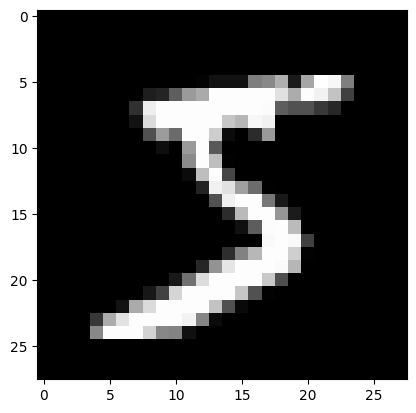

In [49]:
# The observation is made of 28x28 greyscale values (0-255) which can be plot as an image
plt.imshow(X_train_mnist[0], cmap='gray')
plt.show()

For image data, a unique type of Neural Network, called the Convolutional Neural Network, is used. Here we will flatten the greyscale image to convert it to vector form that is usable by our simple Neural Network. 

* .reshape(-1, 28*28) flattens the 28x28 vector to 784x1 vector (-1 lets NumPy identify the arbitrary number of observations in X_train_mnist). 

* .astype('float32') converts pixel value to decimal form

* / 255.0 normalizes the values between 0 and 1



In [50]:
# Preprocess: flatten images and normalize pixel values
X_train_mnist = X_train_mnist.reshape(-1, 28*28).astype('float32') / 255.0
X_test_mnist = X_test_mnist.reshape(-1, 28*28).astype('float32') / 255.0

In [ ]:
# Build a fully connected neural network
mnist_model = tf.keras.Sequential([
    tf.keras.layers.Dense(128,activation="relu",input_shape=(784,)), # h.l 1
    tf.keras.layers.Dense(64,activation="relu"), # h.l 2
    tf.keras.layers.Dense(10,activation="softmax") # o.l
])

# Compile the model using sparse_categorical_crossentropy - not one hot-encoded
mnist_model.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
mnist_model.fit(X_train_mnist, y_train_mnist, epochs=5, batch_size=32, validation_split=0.1)

Epoch 1/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 476us/step - accuracy: 0.8161 - loss: 0.6875 - val_accuracy: 0.9207 - val_loss: 0.2787
Epoch 2/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 439us/step - accuracy: 0.9129 - loss: 0.3026 - val_accuracy: 0.9373 - val_loss: 0.2255
Epoch 3/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 442us/step - accuracy: 0.9279 - loss: 0.2492 - val_accuracy: 0.9470 - val_loss: 0.1899
Epoch 4/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 443us/step - accuracy: 0.9374 - loss: 0.2161 - val_accuracy: 0.9560 - val_loss: 0.1621
Epoch 5/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 443us/step - accuracy: 0.9450 - loss: 0.1904 - val_accuracy: 0.9615 - val_loss: 0.1463
Epoch 6/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 442us/step - accuracy: 0.9503 - loss: 0.1712 - val_accuracy: 0.9630 - val_loss: 0.1342
Epoch 7/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 444us/step - accuracy: 0.9540 - loss: 0.1556 - val_accuracy: 0.9662 - val_loss: 0.1261
Epoch 8/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 430us/step - accuracy: 0.9589 -

Let's now use a test image to evaluate our model. Since we used sparse_categorical_crossentropy, each node in the output layer represents a digit. 

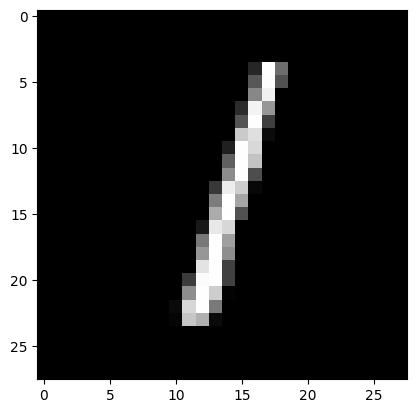

In [54]:
plt.imshow(X_test_mnist[2].reshape(28, 28), cmap='gray')
plt.show()

In [55]:
input_image = X_test_mnist[2:3]

predictions = mnist_model.predict(input_image)

for i in range(10):
    print(f"Probability of digit {i}: {predictions[0][i]:.4f}") 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Probability of digit 0: 0.0000
Probability of digit 1: 0.9880
Probability of digit 2: 0.0029
Probability of digit 3: 0.0010
Probability of digit 4: 0.0003
Probability of digit 5: 0.0007
Probability of digit 6: 0.0007
Probability of digit 7: 0.0042
Probability of digit 8: 0.0018
Probability of digit 9: 0.0002
